## Reading dataset
Lets read MNIST dataset and display first few images

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Step 1: Load the MNIST dataset.
It has 60,000 images for training and 10,000 images for testing.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Step 2: Display the shape of the dataset
print(f"X_train shape: {X_train.shape}")  # (60000, 28, 28).
print(f"y_train shape: {y_train.shape}")  # (60000,)
print(f"X_test shape: {X_test.shape}")    # (10000, 28, 28)
print(f"y_test shape: {y_test.shape}")    # (10000,)


X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


**EDA**

Lets try to see and visualize our data.

(28, 28)
--------------------
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 

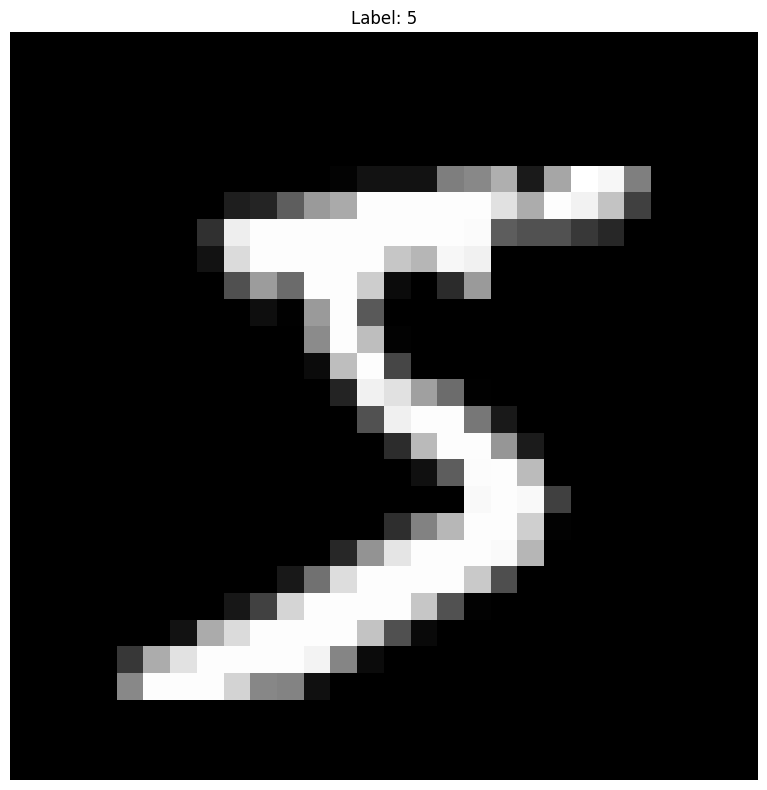

In [3]:
# Lets look at the first image data and also plot it. We are trybing to understand the image data
img_idx=0

print(X_train[img_idx].shape)
print("--------------------")

np.set_printoptions(linewidth=150, precision=2, suppress=True)  # Adjust formatting
print(X_train[img_idx])
print("*********************")

plt.figure(figsize=(8,8))  # Set the figure size

plt.imshow(X_train[img_idx],
           cmap='gray' # # Display the image in grayscale. comment it out if u want to see color
)
plt.title(f"Label: {y_train[img_idx]}")  # Set the title as the label
plt.axis('off')  # Turn off axis
plt.tight_layout()
plt.show()


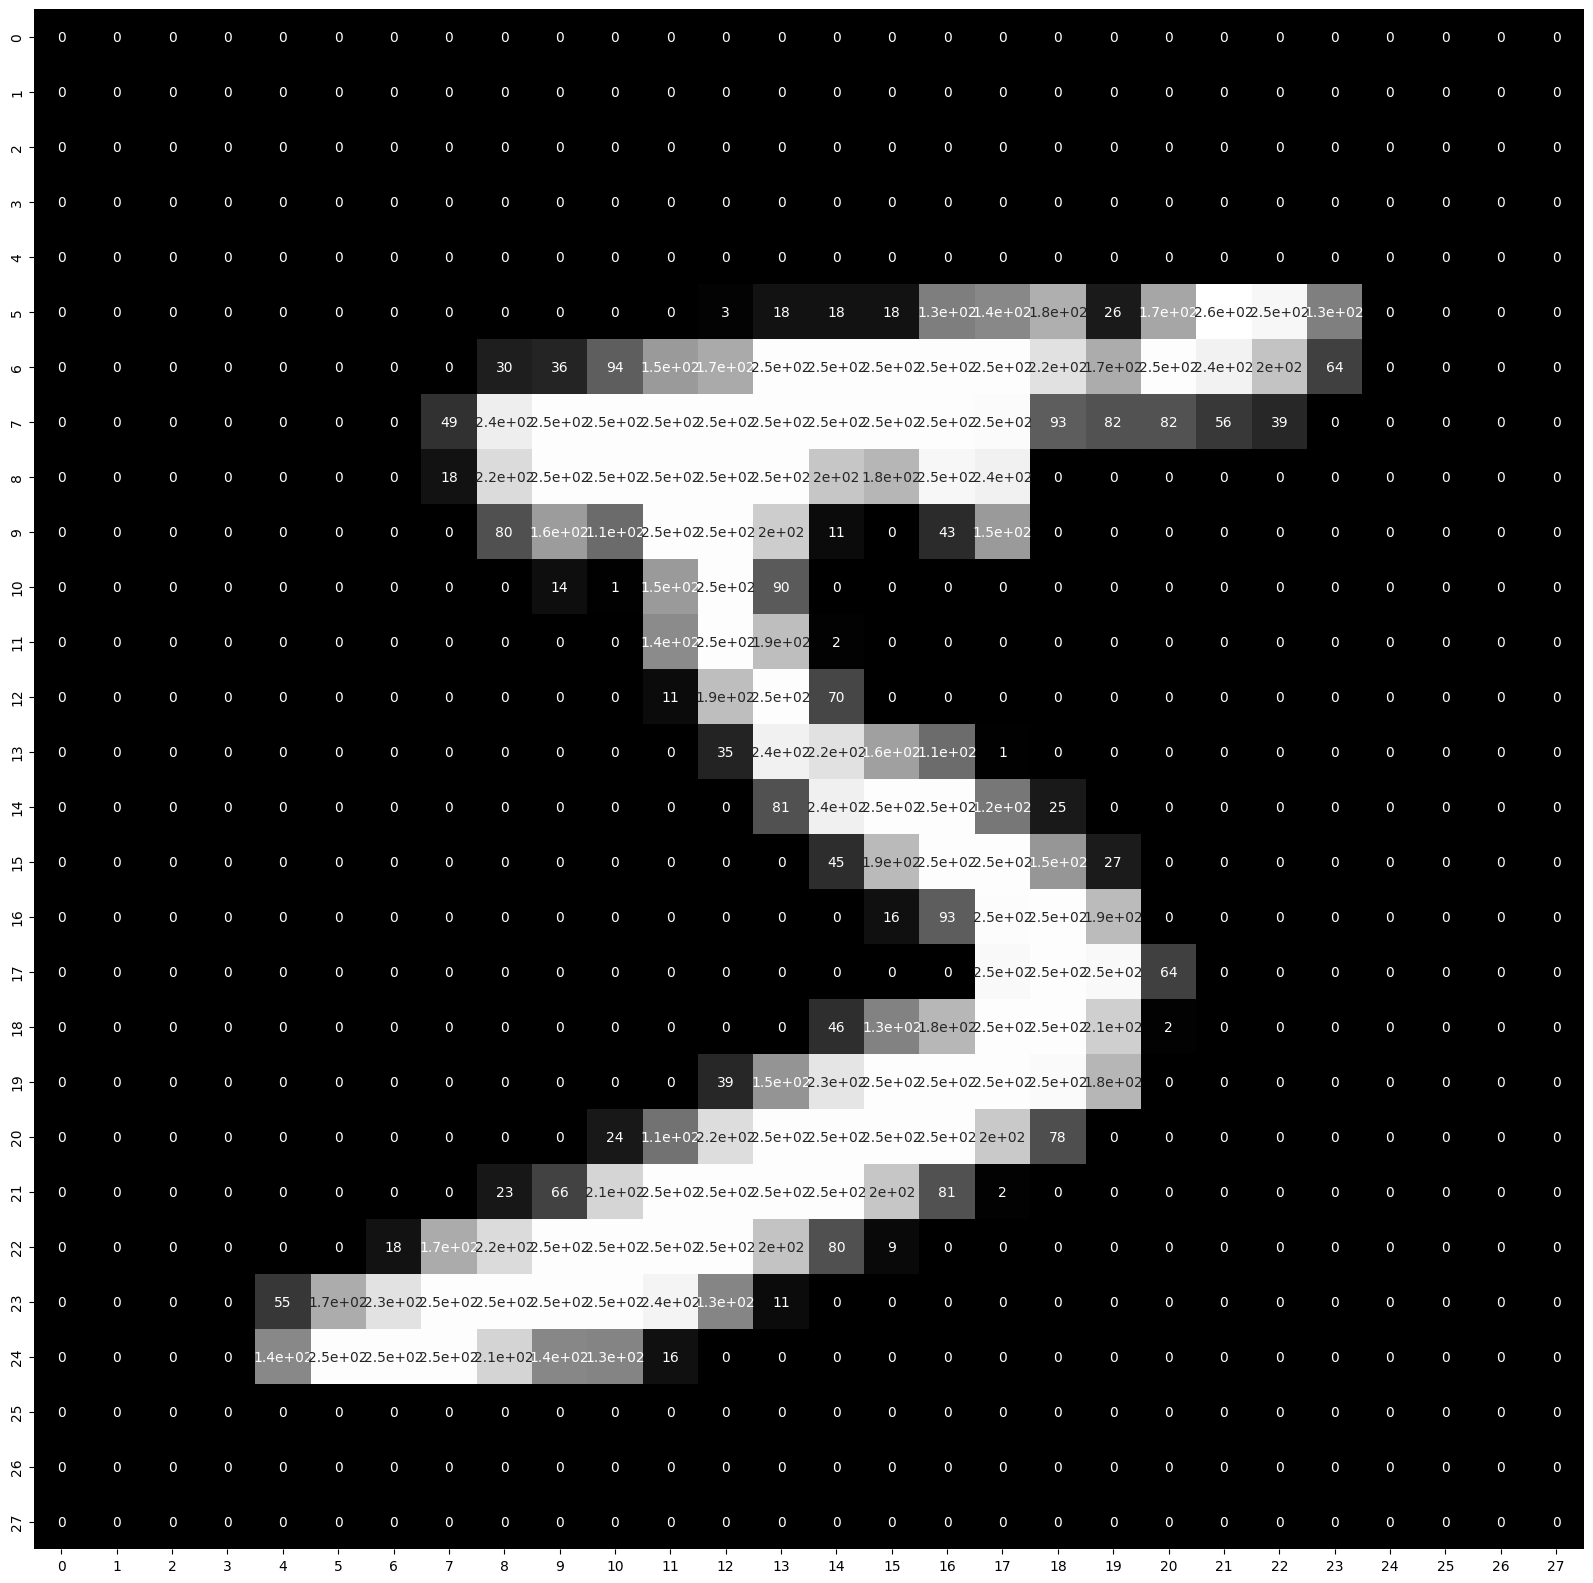

In [4]:
# Lets visualize above using heatmap. # TODO Fix the values that are displayed in scientific notation
plt.figure(figsize=(20, 20))
sns.heatmap(X_train[img_idx], annot=True, cmap="gray", cbar=False)
plt.show()

Lets understand above data. The first image, which is 5, has 28 rows and 28 columns. It is so because this is image size 28 X 28. Each value in the row,col is from 0-255, which is color range. 0 being black and 255 being white

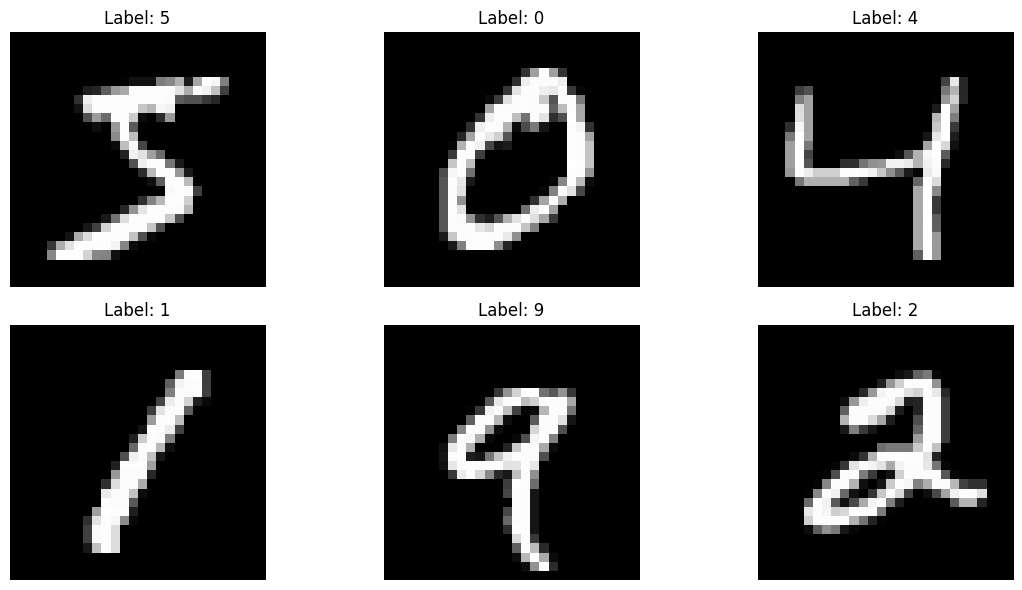

In [5]:
# Display the first 6 images with their labels
plt.figure(figsize=(12, 6))  # Set the figure size
for i in range(6):
    plt.subplot(2, 3, i + 1)  # Create a 2x3 grid for 6 images
    plt.imshow(X_train[i], cmap='gray')  # Display the image in grayscale
    plt.title(f"Label: {y_train[i]}")  # Set the title as the label
    plt.axis('off')  # Turn off axis
plt.tight_layout()
plt.show()


In [6]:
# Now we convert the 28X28 image data, which is a 2D array, into 1D array whose size would be 28*28=784.
# We do this becuase the input layer of Neural Network accepts only 1D data.

X_train = X_train.reshape(-1, 784).astype('float32') / 255.0  # Flatten and normalize training data
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0    # Flatten and normalize test data

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [7]:
#Lets look at the value of 1st image now and compare with above
print(X_train[0]) # This is 1D array whose size is 784

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.01 0.07 0.07 0.07 0.49 0.53 0.69 0.1  0.65 1.   0.97 0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.12 0.14 0.37 0.6  0.67 0.99 0.99 0.99 0.99 0.99 0.88 0.67 0.99 0.95 0.76 0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   

## Creating a Simple Neural Network using tf.keras
tf.keras is TensorFlow's high-level API to build and train deep learning models. You can define models using the Sequential class for a simple stack of layers


In [7]:
# Lets create a simple model which takes input 28*28=784 features, and produces output that are in 10 classes(0-9)
import tensorflow as tf
from tensorflow.keras import layers, models

# Create a simple sequential model
# Input layer (28*28=784 features). 64 is the number of neuron in hidden fully connected layer (dense layer)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')  # Output layer (10 classes)
])



c:\Users\hi\Desktop\projects\python_projects\tutorial\tut_tensorflow\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


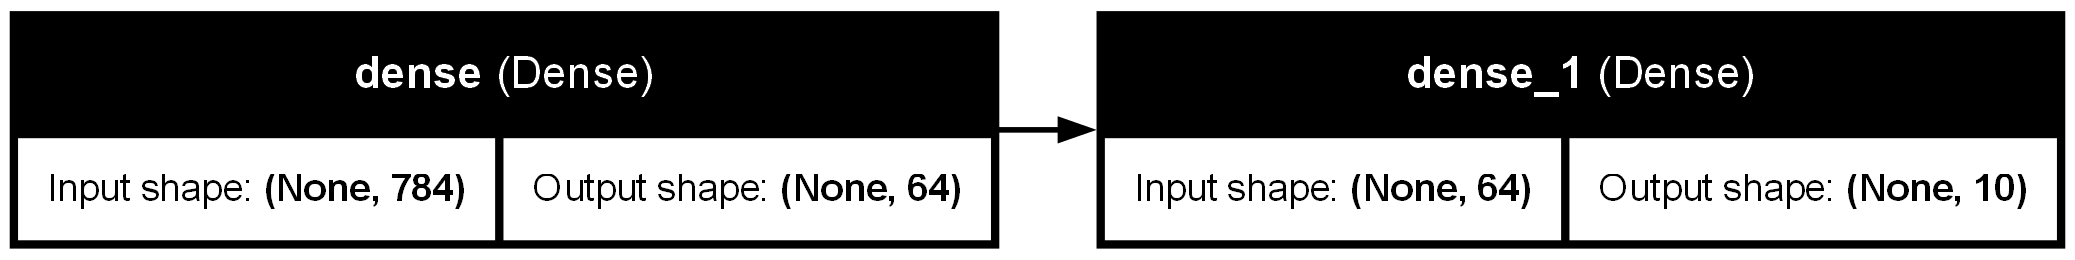

In [8]:
# Lets visualize
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # TB Top to Bottom (vertical)
)


In [9]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model summary to see the architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

## Train above model
Lets use above model

To train a model, you need data. You can use tf.data to load datasets efficiently, and you can train models using the .fit() method on the dataset.

Example (Training a model on MNIST data): ( took 2 minutes)

In [9]:
# 60000/32 = 1688 
# Train the model
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)  # Train for 5 epochs. Took 30 secs

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.2f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8456 - loss: 0.5361 - val_accuracy: 0.9553 - val_loss: 0.1613
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9497 - loss: 0.1733 - val_accuracy: 0.9655 - val_loss: 0.1213
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9656 - loss: 0.1173 - val_accuracy: 0.9728 - val_loss: 0.0940
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9747 - loss: 0.0873 - val_accuracy: 0.9715 - val_loss: 0.0982
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9783 - loss: 0.0711 - val_accuracy: 0.9730 - val_loss: 0.0928
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.1080 
Test accuracy: 0.97


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predictions for the first test sample:
Predicted label: 7
True label: 7


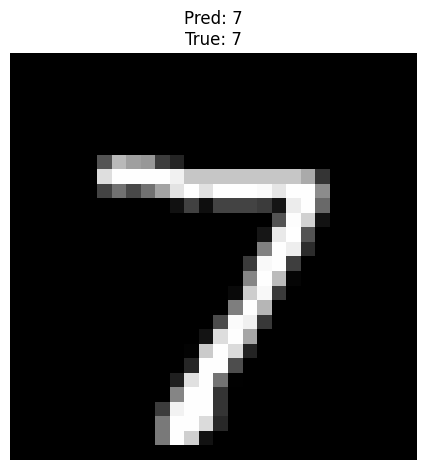

In [ ]:
# Make predictions on one image
predictions = model.predict(X_test[0].reshape(1, -1))  # Predict on the first sample
predicted_labels = predictions.argmax(axis=1)

print("Predictions for the first test sample:")
print("Predicted label:", predicted_labels[0])  # Print predicted class label
print("True label:", y_test[0])  # Print true class label

# Reshape and display the first image
x_test_image = X_test[0].reshape(28, 28)  # Reshape back to 28x28 for visualization

plt.imshow(x_test_image, cmap='gray')  # Display the image
plt.title(f"Pred: {predicted_labels[0]}\nTrue: {y_test[0]}")
plt.axis('off')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Predictions for the first 5 test samples:
[7 2 1 0 4]
True labels: [7 2 1 0 4]


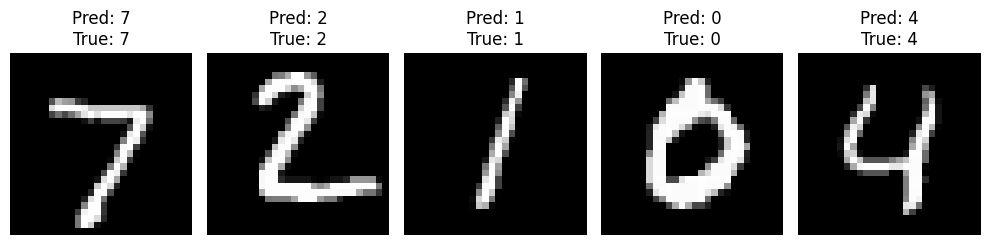

In [ ]:
# Make predictions on 1st 5 test images
predictions = model.predict(X_test[:5])  # Predict on the first 5 samples of the test set
predicted_labels = predictions.argmax(axis=1)

print("Predictions for the first 5 test samples:")
print(predicted_labels)  # Print predicted class labels
print("True labels:", y_test[:5])  # Print true class labels

# Display the first 5 images with predictions
x_test_images = X_test[:5].reshape(-1, 28, 28)  # Reshape back to 28x28 for visualization

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)  # Create subplots for 5 images
    plt.imshow(x_test_images[i], cmap='gray')  # Display the image
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Create and train different model on the same dataset


In [12]:
from tensorflow.keras import layers, models

# Load and prepare the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0
# X_train, X_test = X_train / 255.0, X_test / 255.0

# Build a simple model (as we did previously)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Flatten 28x28 images into 1D
    layers.Dense(128, activation='relu'), # create a dense layer of 128 neuron
    layers.Dropout(0.2), # randomly drop 20% of neuron to prevent overfitting
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model on the MNIST training data
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8601 - loss: 0.4780
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9557 - loss: 0.1490
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9674 - loss: 0.1057
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9722 - loss: 0.0898
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9775 - loss: 0.0715


In [16]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.1009   
Test accuracy: 0.9758999943733215


By increasing model hidden layers and adding drop out layer has increased the accuracy little bit.

## Saving and Loading Models
Once a model is trained, you can save it to disk and load it later for inference or retraining.

Example:

In [ ]:
# Save the model
model.save("model.keras")

In [ ]:
# Load the model back
loaded_model = tf.keras.models.load_model("model.keras")

# Evaluate the loaded model
test_loss, test_acc = loaded_model.evaluate(X_test, y_test)
print(f'Loaded model test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.9722 - loss: 0.0893 
Loaded model test accuracy: 0.9767000079154968
